# Classification with a Neural Network

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture introducing the **neural network**
(Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- a neural network as **perceptrons organized in layers**
- why one perceptron (a single line) isn't enough, and how a hidden layer helps
- the two-layer architecture: input → hidden (two perceptrons) → output
- the math of every node: $a_1, a_2$ and $\hat{y}$ via summations and sigmoids
- the log loss for the network, a forward-pass implementation, and an **XOR** demo
  showing the nonlinear boundary a network can draw

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Classification with a Perceptron — Calculating the Derivatives*.

## 1. Introduction

> *"A neural network is just a bunch of perceptrons organized in layers, where the
> information of these perceptrons is passed to the next layer."*

A single perceptron can only build a **linear boundary** — a straight line between the two
classes. Real problems (like language) may need **curved** boundaries. The fix: connect
several perceptrons into a **network**.

Training still uses **gradient descent**, except now there are many more weights and biases
(hence many more derivatives).

After this notebook you will be able to:

- describe a two-layer neural network and its layers
- write the forward-pass math for every node
- see why a hidden layer lets the model separate non-linearly-separable data

## 2. From one perceptron to a network

Take the red perceptron and add a green one beneath it — two perceptrons that can learn to
do *different* things. Feed **their outputs** into a third, the purple perceptron. That is a
(small) neural network:

- **Input layer:** the features $x_1, x_2$
- **Hidden layer:** the red and green perceptrons, outputs $a_1$ and $a_2$
- **Output layer:** the purple perceptron, output $\hat{y}$

Stacking many such layers lets a network solve very complex problems. We use just two
layers here so the math stays manageable.

## 3. The math, node by node

**Red hidden perceptron** — weights $w_{11}, w_{21}$, bias $b_1$:

$$
z_1 = x_1 w_{11} + x_2 w_{21} + b_1, \qquad a_1 = \sigma(z_1).
$$

**Green hidden perceptron** — weights $w_{12}, w_{22}$, bias $b_2$:

$$
z_2 = x_1 w_{12} + x_2 w_{22} + b_2, \qquad a_2 = \sigma(z_2).
$$

**Purple output perceptron** — its inputs are $a_1, a_2$, weights $w_1, w_2$, bias $b$:

$$
z = a_1 w_1 + a_2 w_2 + b, \qquad \hat{y} = \sigma(z).
$$

So the hidden outputs become the inputs of the output neuron.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def neural_network(x1, x2, params):
    # hidden layer
    z1 = x1*params['w11'] + x2*params['w21'] + params['b1']
    z2 = x1*params['w12'] + x2*params['w22'] + params['b2']
    a1, a2 = sigmoid(z1), sigmoid(z2)
    # output layer
    z = a1*params['w1'] + a2*params['w2'] + params['b']
    y_hat = sigmoid(z)
    return y_hat, a1, a2

# example parameters (illustrative)
params = dict(w11=20, w21=20, b1=-10,    # red  ~ OR
              w12=20, w22=20, b2=-30,    # green ~ AND
              w1=20, w2=-20, b=-10)      # purple ~ OR AND NOT AND

yh, a1, a2 = neural_network(1.0, 0.0, params)
print(f"input (1,0): a1={a1:.3f}, a2={a2:.3f}, y_hat={yh:.3f}")

input (1,0): a1=1.000, a2=0.000, y_hat=1.000


## 4. A picture of the network

Two inputs feed both hidden perceptrons; the hidden outputs feed the output perceptron.

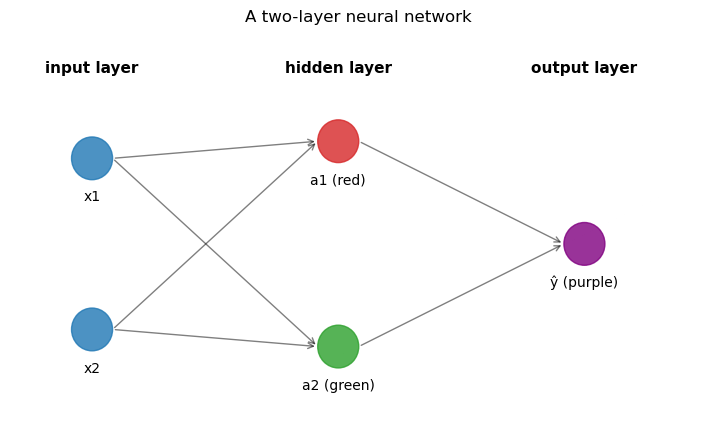

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

nodes = {
    "x1": (0, 3, "tab:blue"),  "x2": (0, 1, "tab:blue"),
    "a1 (red)": (3, 3.2, "tab:red"), "a2 (green)": (3, 0.8, "tab:green"),
    "ŷ (purple)": (6, 2, "purple"),
}
for name, (x, y, c) in nodes.items():
    ax.add_patch(plt.Circle((x, y), 0.25, color=c, alpha=0.8))
    ax.text(x, y - 0.5, name, ha="center", fontsize=10)

edges = [("x1", "a1 (red)"), ("x2", "a1 (red)"),
         ("x1", "a2 (green)"), ("x2", "a2 (green)"),
         ("a1 (red)", "ŷ (purple)"), ("a2 (green)", "ŷ (purple)")]
for u, v in edges:
    x0, y0, _ = nodes[u]; x1n, y1n, _ = nodes[v]
    ax.annotate("", xy=(x1n-0.25, y1n), xytext=(x0+0.25, y0),
                arrowprops=dict(arrowstyle="->", alpha=0.5))

ax.text(0, 4, "input layer", ha="center", fontsize=11, weight="bold")
ax.text(3, 4, "hidden layer", ha="center", fontsize=11, weight="bold")
ax.text(6, 4, "output layer", ha="center", fontsize=11, weight="bold")
ax.set_xlim(-1, 7.5); ax.set_ylim(0, 4.5); ax.axis("off")
ax.set_title("A two-layer neural network")
plt.show()

## 5. The loss function

Since this is a **classification** problem, the error is the **log loss** from the earlier
lecture:

$$
L(y, \hat{y}) = -\,y\log(\hat{y}) - (1-y)\log(1-\hat{y}),
$$

where $\hat{y}$ is the network's prediction and $y$ is the target label.

In [3]:
def log_loss(y, y_hat, eps=1e-12):
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -y*np.log(y_hat) - (1-y)*np.log(1-y_hat)

print("example log loss (y=1, prediction above):", round(float(log_loss(1, yh)), 4))

example log loss (y=1, prediction above): 0.0


## 6. Why a hidden layer? The XOR problem

A single perceptron can only separate data with a **straight line**. The classic example it
**cannot** solve is **XOR**:

| $x_1$ | $x_2$ | label |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

No single line separates the 1s from the 0s. But a two-layer network can, by combining two
hidden boundaries. Our illustrative parameters above implement
"(OR) **and not** (AND)" — exactly XOR.

In [4]:
XOR = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
labels = np.array([0, 1, 1, 0])

print("Neural-network predictions on XOR:")
for (x1, x2), lab in zip(XOR, labels):
    yh, _, _ = neural_network(x1, x2, params)
    print(f"  ({x1:.0f},{x2:.0f}): ŷ={yh:.3f} -> {int(yh>=0.5)}  (target {lab})")

Neural-network predictions on XOR:
  (0,0): ŷ=0.000 -> 0  (target 0)
  (0,1): ŷ=1.000 -> 1  (target 1)
  (1,0): ŷ=1.000 -> 1  (target 1)
  (1,1): ŷ=0.000 -> 0  (target 0)


### The network's nonlinear decision boundary

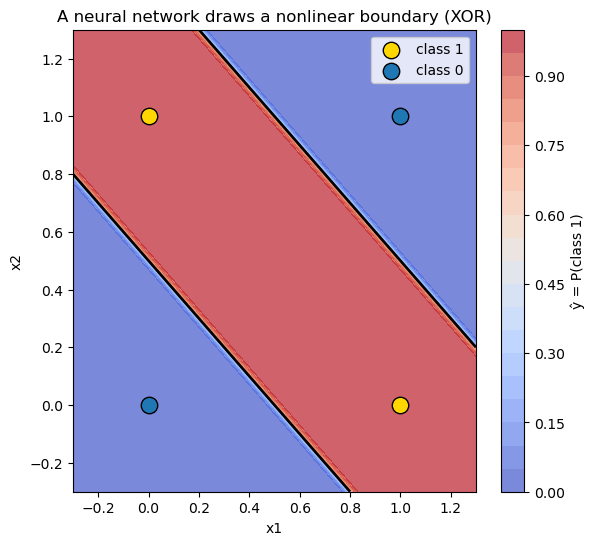

In [5]:
gx = np.linspace(-0.3, 1.3, 200)
gy = np.linspace(-0.3, 1.3, 200)
GX, GY = np.meshgrid(gx, gy)
GZ, _, _ = neural_network(GX, GY, params)

plt.figure(figsize=(6.5, 6))
cf = plt.contourf(GX, GY, GZ, levels=20, cmap="coolwarm", alpha=0.7)
plt.colorbar(cf, label="ŷ = P(class 1)")
plt.contour(GX, GY, GZ, levels=[0.5], colors="black", linewidths=2)
ones = XOR[labels == 1]; zeros = XOR[labels == 0]
plt.scatter(ones[:,0], ones[:,1], s=140, color="gold", edgecolor="black", label="class 1")
plt.scatter(zeros[:,0], zeros[:,1], s=140, color="tab:blue", edgecolor="black", label="class 0")
plt.title("A neural network draws a nonlinear boundary (XOR)")
plt.xlabel("x1"); plt.ylabel("x2"); plt.legend()
plt.show()

## 7. Exercises

### Basic
1. Name the three layers of the network and what each produces.
2. Write the equations for $a_1$, $a_2$, and $\hat{y}$.

### Intermediate
3. Compute $a_1, a_2, \hat{y}$ for input $(1, 1)$ with the illustrative parameters.
4. Why can't a single perceptron solve XOR?

### Advanced
5. Change the output weights to $w_1 = w_2 = 20$, $b = -10$ (an OR gate at the output) and
   describe how the predictions on XOR change.
6. Explain, in terms of layers, how adding more hidden units or layers lets a network model
   more complex boundaries.

## 8. Solutions / Checks

In [6]:
# 3.
yh, a1, a2 = neural_network(1.0, 1.0, params)
print(f"3. (1,1): a1={a1:.3f}, a2={a2:.3f}, y_hat={yh:.3f}")

# 5. change output to OR gate
p_or = dict(params); p_or.update(w1=20, w2=20, b=-10)
print("5. with output as OR:")
for (x1, x2), lab in zip(XOR, labels):
    yo, _, _ = neural_network(x1, x2, p_or)
    print(f"   ({x1:.0f},{x2:.0f}): ŷ={yo:.3f}  (XOR target {lab})  -> no longer XOR")

print("4. XOR's two positive points are diagonal, so no single straight line separates "
      "them from the negatives; a perceptron only makes straight lines.")
print("6. Each hidden unit adds a boundary; combining many across layers composes them into "
      "arbitrarily complex shapes.")

3. (1,1): a1=1.000, a2=1.000, y_hat=0.000
5. with output as OR:
   (0,0): ŷ=0.000  (XOR target 0)  -> no longer XOR
   (0,1): ŷ=1.000  (XOR target 1)  -> no longer XOR
   (1,0): ŷ=1.000  (XOR target 1)  -> no longer XOR
   (1,1): ŷ=1.000  (XOR target 0)  -> no longer XOR
4. XOR's two positive points are diagonal, so no single straight line separates them from the negatives; a perceptron only makes straight lines.
6. Each hidden unit adds a boundary; combining many across layers composes them into arbitrarily complex shapes.


## 9. Conclusion

- A **neural network** is perceptrons arranged in **layers**, each layer's outputs feeding
  the next.
- The two-layer network computes hidden activations
  $a_1 = \sigma(x_1 w_{11} + x_2 w_{21} + b_1)$,
  $a_2 = \sigma(x_1 w_{12} + x_2 w_{22} + b_2)$, then
  $\hat{y} = \sigma(a_1 w_1 + a_2 w_2 + b)$.
- The hidden layer lets it draw **nonlinear** boundaries — solving problems like XOR that a
  single perceptron cannot.
- Training uses the **log loss** and **gradient descent**, now with many weights and biases
  — the chain rule applied through the layers, i.e. **backpropagation**, comes next.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_08.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture introducing the **neural network**. Key spoken points, lightly
cleaned:

> A neural network is a bunch of perceptrons organized in layers, each layer's information
> passed to the next, trained with gradient descent — now with many derivatives. A single
> perceptron only builds a linear boundary, but language may need more complex ones. So we
> combine perceptrons: a red and a green perceptron whose outputs feed a purple perceptron —
> that is a neural network with an input layer, a hidden layer, and an output layer. The
> red gives $a_1 = \sigma(z_1)$ with $z_1 = x_1 w_{11} + x_2 w_{21} + b_1$; the green gives
> $a_2 = \sigma(z_2)$ with $z_2 = x_1 w_{12} + x_2 w_{22} + b_2$; the purple takes $a_1, a_2$
> as inputs with weights $w_1, w_2$ and bias $b$, forming $z = a_1 w_1 + a_2 w_2 + b$ and
> $\hat{y} = \sigma(z)$. The error is the log loss $L(y,\hat{y}) = -y\log\hat{y} -
> (1-y)\log(1-\hat{y})$. Now we're ready to train them.